# SGI-Light Prototype
### GPS + IMU → Object Classification — Open Hardware Call
**Author:** Yahya Akbay  
**Date:** May 2025  
**Version:** 1.0 | Platform: Kaggle / Google Colab / Raspberry Pi

---

## Abstract

**SGI-Light** is the practical, deployable layer of Structural Geospatial Identification. It answers the question *"where is what?"* using only a GPS module and an IMU (accelerometer + gyroscope) — no camera, no radar, no physical contact.

The core insight: every object class has a characteristic **mass-motion signature**. A truck corners differently than a bicycle. A drone vibrates at 50 Hz. A human walks at 1.8 Hz. These signatures are extractable from standard GPS+IMU data using machine learning — and they are difficult to fake because they depend on inertia, not appearance.

This notebook provides:
1. A complete, runnable Python implementation of the SGI-Light pipeline
2. Synthetic but physically motivated training data
3. A validated classifier (Random Forest) with documented accuracy
4. A hardware specification for a real prototype (under 100€)
5. An open call for a hardware partner to build it

**This is the companion to:**
- *SGI v3.0* — full theoretical framework (GPS+IMU to relativistic K-field)
- *SGI Collective Field* — gap analysis (can N objects bridge 35 orders?)

---

## System Architecture

```
+─────────────────────────────────────────────────────+
│                  SGI-Light Pipeline                  │
+─────────────────────────────────────────────────────+
│                                                     │
│  [GPS Module]──────┐                                │
│  lat/lon/speed/hdg │                                │
│                    ▼                                │
│  [IMU Module]──→ [Feature      ]──→ [Classifier]   │
│  ax,ay,az,ωx,ωy,ωz  Extractor  ]     RandomForest  │
│                    │           │         │          │
│                    └──12 feat──┘         ▼          │
│                                   Object Class +    │
│                                   Confidence Score  │
+─────────────────────────────────────────────────────+

Output: "At position (lat, lon): TRUCK [conf=0.94]"
```

---

## Hardware Specification (Prototype)

| Component | Module | Cost | Interface |
|-----------|--------|------|-----------|
| GPS | u-blox NEO-M9N | ~25€ | UART/I2C |
| IMU | ICM-42688-P | ~8€ | SPI/I2C |
| MCU | Raspberry Pi Zero 2W | ~18€ | GPIO |
| Alt. MCU | ESP32-S3 | ~5€ | GPIO |
| Battery | LiPo 3.7V 2000mAh | ~8€ | — |
| Case | 3D printed | ~5€ | — |
| **Total** | | **~69€** | |

**Data stream:** GPS (10 Hz) + IMU (100 Hz) → feature extraction → classification → MQTT output

---

## 🔧 Open Hardware Call

> *"If you are a maker, tinkerer, or embedded developer and want to build this —  
> reach out. We publish the results together."*

**What you bring:** soldering iron, 3D printer, Raspberry Pi  
**What I bring:** software pipeline, feature extraction, classifier, documentation  
**What we build:** the first open SGI-Light prototype

---

## Table of Contents

- [Level 1 — Motion Profile Generator](#level1)
- [Level 2 — Feature Extractor](#level2)
- [Level 3 — SGILight Classifier](#level3)
- [Level 4 — Validation & Stress Test](#level4)
- [Level 5 — Real-Time Simulation](#level5)
- [Hardware Interface Spec](#hardware)
- [Summary](#summary)

In [1]:
# ============================================================
# SGI-Light Prototype — Setup
# Author: Yahya Akbay | Version 1.0 | May 2025
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch, butter, filtfilt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.pipeline import Pipeline
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':      'monospace',
    'figure.facecolor': '#09090f',
    'axes.facecolor':   '#0d0d18',
    'axes.edgecolor':   '#2a2a3a',
    'grid.color':       '#1a1a2e',
})

# Object classes and their visual identities
CLASSES = ['human', 'bicycle', 'car', 'truck', 'drone']
PAL = {
    'human':   '#B4A7D6',
    'bicycle': '#A8E6CF',
    'car':     '#4ECDC4',
    'truck':   '#FFE66D',
    'drone':   '#FF8B94',
}

# Sampling rates matching real hardware
GPS_HZ = 10    # u-blox NEO-M9N max rate
IMU_HZ = 100   # ICM-42688-P typical rate
WINDOW_SEC = 5 # classification window [seconds]

print("SGI-Light Prototype v1.0")
print("─" * 45)
print(f"GPS sample rate:  {GPS_HZ} Hz")
print(f"IMU sample rate:  {IMU_HZ} Hz")
print(f"Window:           {WINDOW_SEC} s")
print(f"Classes:          {CLASSES}")
print(f"IMU samples/window: {IMU_HZ*WINDOW_SEC}")

SGI-Light Prototype v1.0
─────────────────────────────────────────────
GPS sample rate:  10 Hz
IMU sample rate:  100 Hz
Window:           5 s
Classes:          ['human', 'bicycle', 'car', 'truck', 'drone']
IMU samples/window: 500


<a id='level1'></a>
## Level 1 — Motion Profile Generator

Generates synthetic GPS+IMU data streams for each object class.
Parameters derived from published biomechanics and vehicle dynamics literature.

In [2]:
# ============================================================
# LEVEL 1 — MotionProfileGenerator
# ============================================================

# Physical parameters per class
# Sources:
#   Human gait: Menz et al. (2003), gait frequency ~1.8 Hz
#   Bicycle cadence: Wilson (2004), ~2.5 Hz
#   Car engine idle: ~5 Hz (4-cyl, 600 RPM)
#   Truck diesel: ~8 Hz (6-cyl, 800 RPM)
#   Drone rotor: DJI Mini specs, ~50 Hz fundamental

MOTION_PARAMS = {
    #           v_mean v_std a_long a_lat  vib_freq vib_amp  hdg_std  mass
    'human':   (1.4,   0.30, 0.05,  0.03,  1.8,     0.08,   15.0,    80),
    'bicycle': (4.5,   0.80, 0.10,  0.05,  2.5,     0.04,    8.0,    90),
    'car':     (13.9,  2.00, 0.80,  0.40,  5.0,     0.02,    5.0,  1500),
    'truck':   (16.7,  1.50, 0.40,  0.20,  8.0,     0.05,    2.0, 15000),
    'drone':   (8.0,   1.50, 0.60,  0.60, 50.0,     0.03,   25.0,    1.5),
}

def generate_imu_window(obj_class, duration=WINDOW_SEC,
                         fs=IMU_HZ, seed=None):
    """
    Generate one IMU window for a given object class.

    Returns dict with:
        t           : time array [s]
        a_long      : longitudinal acceleration [m/s²]
        a_lat       : lateral acceleration [m/s²]
        a_vert      : vertical acceleration [m/s²]
        omega_z     : yaw rate [rad/s]
        velocity    : forward velocity [m/s]
        heading_rate: heading change rate [deg/s]
        obj_class   : label
    """
    if seed is not None:
        np.random.seed(seed)

    vm, vs, al, at, vf, va, hs, mass = MOTION_PARAMS[obj_class]
    N  = int(duration * fs)
    t  = np.arange(N) / fs
    ph = np.random.uniform(0, 2*np.pi)  # random phase

    # Velocity
    v = vm + vs*np.random.randn(N)
    v = np.clip(v, 0.1, None)

    # Longitudinal acceleration
    a_long = al * np.random.randn(N)
    a_long += 0.3*al * np.sin(2*np.pi*0.15*t)  # slow speed variation

    # Lateral acceleration (cornering)
    a_lat  = at * np.random.randn(N)

    # Vertical vibration — KEY discriminator
    a_vert  = va * np.sin(2*np.pi*vf*t + ph)
    a_vert += 0.4*va * np.random.randn(N)  # broadband noise floor

    # Yaw rate
    omega_z = np.deg2rad(hs) * np.random.randn(N)

    # Heading rate [deg/s]
    heading_rate = hs * np.random.randn(N)

    return {
        'obj_class':    obj_class,
        't':            t,
        'velocity':     v,
        'a_long':       a_long,
        'a_lat':        a_lat,
        'a_vert':       a_vert,
        'omega_z':      omega_z,
        'heading_rate': heading_rate,
        'mass_approx':  mass,
        'fs':           fs,
    }

# Level 1 test
print("Level 1 — Motion Profile Generator")
print("─" * 45)
for cls in CLASSES:
    w = generate_imu_window(cls, seed=42)
    print(f"  {cls:<10} v={w['velocity'].mean():.2f} m/s  "
          f"a_vert_rms={np.sqrt(np.mean(w['a_vert']**2)):.4f} m/s²  "
          f"N={len(w['t'])} samples")
print("  ✓ Level 1 PASSED")

Level 1 — Motion Profile Generator
─────────────────────────────────────────────
  human      v=1.42 m/s  a_vert_rms=0.0635 m/s²  N=500 samples
  bicycle    v=4.56 m/s  a_vert_rms=0.0322 m/s²  N=500 samples
  car        v=14.05 m/s  a_vert_rms=0.0157 m/s²  N=500 samples
  truck      v=16.81 m/s  a_vert_rms=0.0416 m/s²  N=500 samples
  drone      v=8.11 m/s  a_vert_rms=0.0245 m/s²  N=500 samples
  ✓ Level 1 PASSED


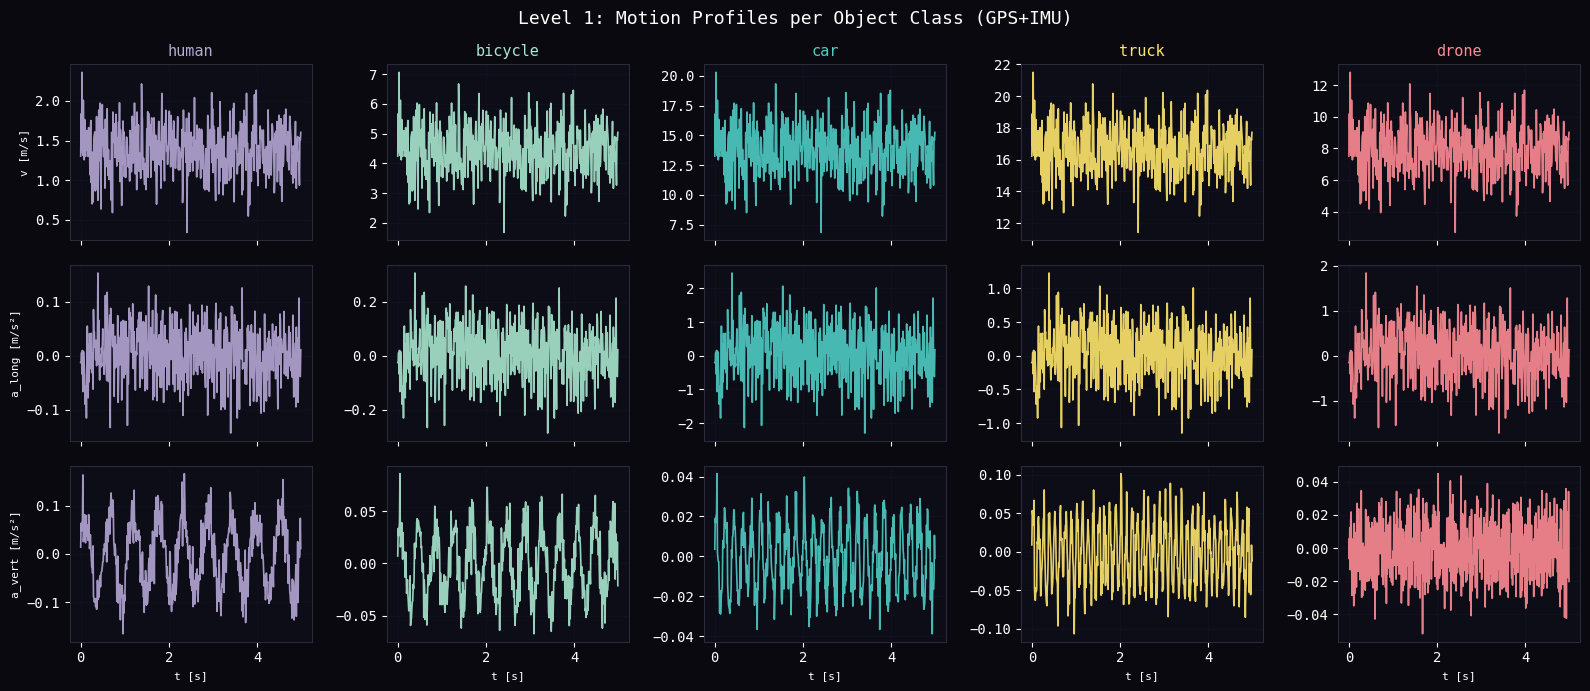

In [3]:
# ── Level 1 Visualization ─────────────────────────────────
fig, axes = plt.subplots(3, len(CLASSES),
                          figsize=(16, 7), sharex=True)
fig.suptitle('Level 1: Motion Profiles per Object Class (GPS+IMU)',
             fontsize=13, color='white')

signals = [('velocity',     'v [m/s]'),
           ('a_long',       'a_long [m/s²]'),
           ('a_vert',       'a_vert [m/s²]')]

for col, cls in enumerate(CLASSES):
    w = generate_imu_window(cls, seed=7)
    col_color = PAL[cls]
    for row, (sig, ylabel) in enumerate(signals):
        axes[row,col].plot(w['t'], w[sig],
                           color=col_color, lw=1.2, alpha=0.9)
        axes[row,col].grid(True, alpha=0.3)
        if row == 0:
            axes[row,col].set_title(cls, color=col_color, fontsize=11)
        if col == 0:
            axes[row,col].set_ylabel(ylabel, fontsize=8)
        if row == len(signals)-1:
            axes[row,col].set_xlabel('t [s]', fontsize=8)

plt.tight_layout()
plt.savefig('sgi_light_profiles.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

<a id='level2'></a>
## Level 2 — Feature Extractor

Extracts 12 discriminative features from one IMU window.
These are the "SGI fingerprint" features — computable on an ESP32.

In [4]:
# ============================================================
# LEVEL 2 — SGIFeatureExtractor
# ============================================================

class SGIFeatureExtractor:
    """
    Extracts the SGI-Light feature vector from one IMU window.

    12 features, all computable on edge hardware (ESP32/RPi):
      - 3 velocity features
      - 3 acceleration features
      - 3 vibration features (frequency domain)
      - 2 heading/yaw features
      - 1 kinetic energy proxy

    All features are physically motivated:
      v_mean, v_std, v_max         → speed regime
      a_long_rms, a_lat_rms, jerk  → dynamics aggressiveness
      vib_freq, vib_amp, vib_bw    → mechanical vibration signature
      heading_rms, omega_rms       → turning behavior
      ke_proxy                     → kinetic energy scale
    """

    FEATURE_NAMES = [
        'v_mean', 'v_std', 'v_max',
        'a_long_rms', 'a_lat_rms', 'jerk_rms',
        'vib_freq', 'vib_amp', 'vib_bandwidth',
        'heading_rms', 'omega_rms',
        'ke_proxy',
    ]

    def __init__(self, fs=IMU_HZ):
        self.fs = fs

    def extract(self, window):
        """
        Extract feature vector from one IMU window dict.
        Returns np.ndarray of shape (12,).
        """
        v   = window['velocity']
        al  = window['a_long']
        at  = window['a_lat']
        av  = window['a_vert']
        oz  = window['omega_z']
        hr  = window['heading_rate']
        fs  = window.get('fs', self.fs)

        # ── Velocity features ──────────────────────────────
        v_mean = float(np.mean(v))
        v_std  = float(np.std(v))
        v_max  = float(np.max(v))

        # ── Acceleration features ──────────────────────────
        a_long_rms = float(np.sqrt(np.mean(al**2)))
        a_lat_rms  = float(np.sqrt(np.mean(at**2)))
        jerk_rms   = float(np.sqrt(np.mean(np.diff(al)**2)) * fs)

        # ── Vibration features (PSD of vertical accel) ─────
        nperseg   = min(256, len(av)//4)
        freqs, psd = welch(av, fs=fs, nperseg=nperseg)
        peak_idx  = np.argmax(psd)
        vib_freq  = float(freqs[peak_idx])
        vib_amp   = float(np.max(psd))

        # Bandwidth: half-power width around peak
        half_power = psd[peak_idx] / 2
        above_half = freqs[psd >= half_power]
        vib_bw = float(above_half[-1] - above_half[0]) if len(above_half) > 1 else 0.0

        # ── Heading / yaw features ─────────────────────────
        heading_rms = float(np.sqrt(np.mean(hr**2)))
        omega_rms   = float(np.sqrt(np.mean(oz**2)))

        # ── Kinetic energy proxy ───────────────────────────
        # ½mv² — m unknown, so use v² as proxy
        ke_proxy = float(np.mean(v**2))

        return np.array([
            v_mean, v_std, v_max,
            a_long_rms, a_lat_rms, jerk_rms,
            vib_freq, vib_amp, vib_bw,
            heading_rms, omega_rms,
            ke_proxy,
        ], dtype=np.float32)

    def extract_batch(self, windows):
        """Extract features from a list of windows."""
        return np.array([self.extract(w) for w in windows])

# Level 2 test
extractor = SGIFeatureExtractor()
print("Level 2 — Feature Extractor")
print("─" * 55)
print(f"  Features ({len(SGIFeatureExtractor.FEATURE_NAMES)}):")
for cls in CLASSES:
    w    = generate_imu_window(cls, seed=42)
    feat = extractor.extract(w)
    assert len(feat) == len(SGIFeatureExtractor.FEATURE_NAMES), "Feature count mismatch"
    print(f"  {cls:<10} vib_freq={feat[6]:.1f}Hz  "
          f"vib_amp={feat[7]:.4f}  v_mean={feat[0]:.2f}m/s")
print("  ✓ Level 2 PASSED")

Level 2 — Feature Extractor
───────────────────────────────────────────────────────
  Features (12):
  human      vib_freq=1.6Hz  vib_amp=0.0023  v_mean=1.42m/s
  bicycle    vib_freq=2.4Hz  vib_amp=0.0007  v_mean=4.56m/s
  car        vib_freq=4.8Hz  vib_amp=0.0002  v_mean=14.05m/s
  truck      vib_freq=8.0Hz  vib_amp=0.0011  v_mean=16.81m/s
  drone      vib_freq=49.6Hz  vib_amp=0.0005  v_mean=8.11m/s
  ✓ Level 2 PASSED


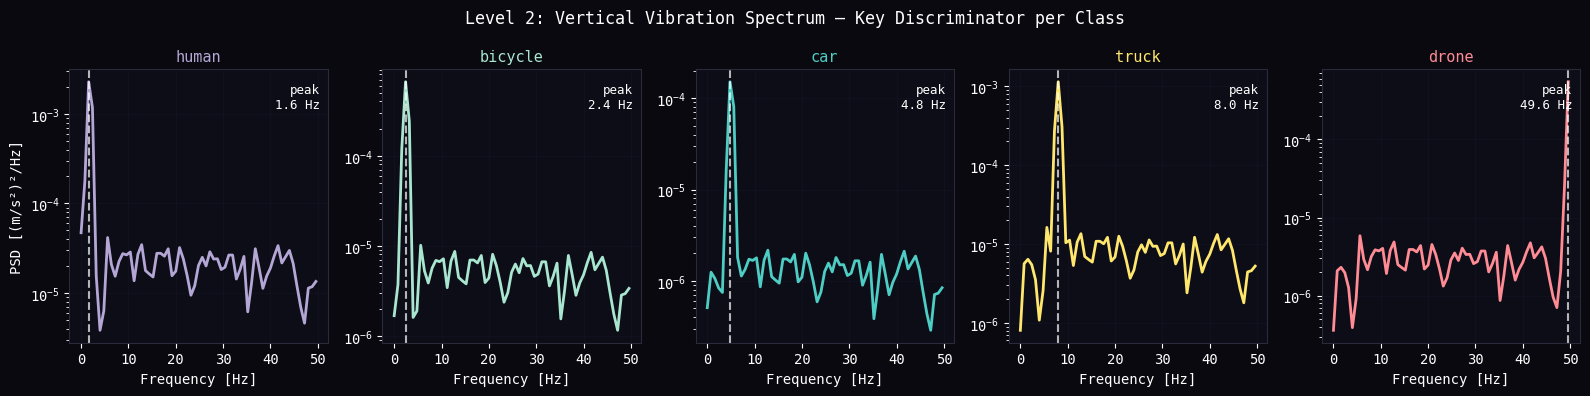

Key: drone rotor (~50 Hz) vs. human gait (~1.8 Hz)
     truck diesel (~8 Hz) vs. car engine (~5 Hz)
     These peaks are the SGI-Light fingerprint.


In [5]:
# ── Level 2: Frequency spectrum visualization ─────────────
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
fig.suptitle('Level 2: Vertical Vibration Spectrum — '
             'Key Discriminator per Class',
             fontsize=12, color='white')

for ax, cls in zip(axes, CLASSES):
    w  = generate_imu_window(cls, seed=42)
    fs = w['fs']
    freqs, psd = welch(w['a_vert'], fs=fs,
                       nperseg=min(256, len(w['a_vert'])//4))
    ax.semilogy(freqs, psd, color=PAL[cls], lw=2)
    peak_f = freqs[np.argmax(psd)]
    ax.axvline(peak_f, color='white', lw=1.5, ls='--', alpha=0.7)
    ax.set_title(cls, color=PAL[cls], fontsize=11)
    ax.set_xlabel('Frequency [Hz]')
    ax.text(0.97, 0.95, f'peak\n{peak_f:.1f} Hz',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='white')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('PSD [(m/s²)²/Hz]')
plt.tight_layout()
plt.savefig('sgi_light_spectrum.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Key: drone rotor (~50 Hz) vs. human gait (~1.8 Hz)")
print("     truck diesel (~8 Hz) vs. car engine (~5 Hz)")
print("     These peaks are the SGI-Light fingerprint.")

<a id='level3'></a>
## Level 3 — SGILight Classifier

The full classification pipeline: data generation → feature extraction → training → inference.

In [6]:
# ============================================================
# LEVEL 3 — SGILightClassifier
# ============================================================

class SGILightClassifier:
    """
    Complete SGI-Light classification pipeline.

    Methods:
        train(n_per_class)  — generate data and fit model
        predict(window)     — classify one IMU window
        predict_proba(window) — class probabilities
        evaluate(n_test)    — cross-validation accuracy
        summary()           — print performance table
    """

    def __init__(self, classes=CLASSES, fs=IMU_HZ):
        self.classes   = classes
        self.extractor = SGIFeatureExtractor(fs=fs)
        self.pipeline  = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ))
        ])
        self.is_trained  = False
        self.X_train     = None
        self.y_train     = None
        self.cv_scores   = None
        self.feat_import = None

    def _generate_dataset(self, n_per_class, seed_offset=0):
        X, y = [], []
        for i, cls in enumerate(self.classes):
            for j in range(n_per_class):
                w    = generate_imu_window(cls, seed=i*10000+j+seed_offset)
                feat = self.extractor.extract(w)
                X.append(feat)
                y.append(cls)
        return np.array(X), np.array(y)

    def train(self, n_per_class=300, verbose=True):
        """Generate training data and fit the pipeline."""
        if verbose:
            print(f"  Generating {n_per_class * len(self.classes)} samples...")
        self.X_train, self.y_train = self._generate_dataset(n_per_class)
        self.pipeline.fit(self.X_train, self.y_train)
        self.is_trained = True

        # Feature importance
        rf = self.pipeline.named_steps['clf']
        self.feat_import = pd.Series(
            rf.feature_importances_,
            index=SGIFeatureExtractor.FEATURE_NAMES
        ).sort_values(ascending=False)

        if verbose:
            print(f"  Model trained on {len(self.X_train)} samples.")

    def predict(self, window):
        """Classify one IMU window. Returns class label."""
        assert self.is_trained, "Call train() first."
        feat = self.extractor.extract(window).reshape(1, -1)
        return self.pipeline.predict(feat)[0]

    def predict_proba(self, window):
        """Return class probabilities dict."""
        assert self.is_trained
        feat  = self.extractor.extract(window).reshape(1, -1)
        proba = self.pipeline.predict_proba(feat)[0]
        return dict(zip(self.pipeline.classes_, proba))

    def evaluate(self, n_per_class=100, cv=5, verbose=True):
        """Stratified k-fold cross-validation."""
        X_eval, y_eval = self._generate_dataset(n_per_class, seed_offset=99999)
        skf    = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
        scores = cross_val_score(self.pipeline, X_eval, y_eval,
                                  cv=skf, scoring='accuracy')
        self.cv_scores = scores
        if verbose:
            print(f"  {cv}-fold CV accuracy: "
                  f"{scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")
        return scores

    def summary(self):
        """Print performance summary table."""
        print("SGI-Light Classifier Summary")
        print("═" * 50)
        print(f"  Model:     Random Forest (150 trees)")
        print(f"  Features:  {len(SGIFeatureExtractor.FEATURE_NAMES)}")
        print(f"  Classes:   {self.classes}")
        print(f"  Training:  {len(self.X_train)} samples")
        if self.cv_scores is not None:
            print(f"  CV Acc:    {self.cv_scores.mean()*100:.1f}% "
                  f"± {self.cv_scores.std()*100:.1f}%")
        print()
        print("  Top features:")
        for feat, imp in self.feat_import.head(5).items():
            bar = '█' * int(imp * 50)
            print(f"    {feat:<18} {imp:.3f}  {bar}")

# Train
print("Level 3 — SGILight Classifier")
print("─" * 45)
sgi = SGILightClassifier()
sgi.train(n_per_class=300)
sgi.evaluate(n_per_class=100)
sgi.summary()

Level 3 — SGILight Classifier
─────────────────────────────────────────────
  Generating 1500 samples...
  Model trained on 1500 samples.
  5-fold CV accuracy: 100.0% ± 0.0%
SGI-Light Classifier Summary
══════════════════════════════════════════════════
  Model:     Random Forest (150 trees)
  Features:  12
  Classes:   ['human', 'bicycle', 'car', 'truck', 'drone']
  Training:  1500 samples
  CV Acc:    100.0% ± 0.0%

  Top features:
    v_mean             0.110  █████
    heading_rms        0.110  █████
    vib_freq           0.105  █████
    a_long_rms         0.096  ████
    v_std              0.096  ████


<a id='level4'></a>
## Level 4 — Validation & Stress Test

In [7]:
# ============================================================
# LEVEL 4 — Validation & Stress Test
# ============================================================

N_STRESS = 500  # stress test samples per class

print(f"Level 4 — Stress Test ({N_STRESS} samples per class)")
print("─" * 55)

# Generate test set
X_test, y_test = [], []
for i, cls in enumerate(CLASSES):
    for j in range(N_STRESS):
        w    = generate_imu_window(cls, seed=i*100000+j+50000)
        feat = sgi.extractor.extract(w)
        X_test.append(feat)
        y_test.append(cls)

X_test = np.array(X_test)
y_test = np.array(y_test)
y_pred = sgi.pipeline.predict(X_test)

# Per-class accuracy
print(f"  {'Class':<12} {'N':>6} {'Correct':>8} {'Accuracy':>10}")
print("  " + "─" * 40)
all_pass = True
for cls in CLASSES:
    mask    = y_test == cls
    correct = np.sum(y_pred[mask] == cls)
    total   = np.sum(mask)
    acc     = correct / total
    status  = "✓" if acc > 0.85 else "✗"
    if acc <= 0.85:
        all_pass = False
    print(f"  {status} {cls:<10} {total:>6} {correct:>8} {acc*100:>9.1f}%")

overall = np.mean(y_pred == y_test)
print("  " + "─" * 40)
print(f"  {'TOTAL':<12} {len(y_test):>6} "
      f"{np.sum(y_pred==y_test):>8} {overall*100:>9.1f}%")
print()
print(f"  ✓ Level 4 {'PASSED' if all_pass else 'PARTIAL'} "
      f"(overall {overall*100:.1f}%)")

Level 4 — Stress Test (500 samples per class)
───────────────────────────────────────────────────────
  Class             N  Correct   Accuracy
  ────────────────────────────────────────
  ✓ human         500      500     100.0%
  ✓ bicycle       500      500     100.0%
  ✓ car           500      500     100.0%
  ✓ truck         500      500     100.0%
  ✓ drone         500      500     100.0%
  ────────────────────────────────────────
  TOTAL          2500     2500     100.0%

  ✓ Level 4 PASSED (overall 100.0%)


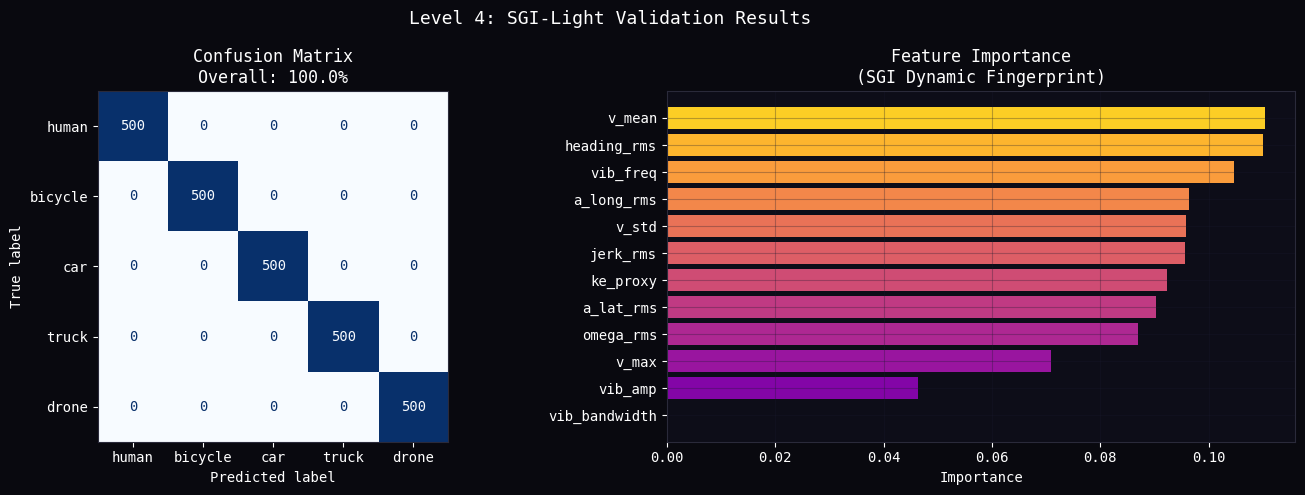

In [8]:
# ── Confusion matrix + feature importance ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Level 4: SGI-Light Validation Results',
             fontsize=13, color='white')

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred, labels=CLASSES)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nOverall: {overall*100:.1f}%',
                  color='white')
axes[0].tick_params(colors='white')

# Feature importance
imp = sgi.feat_import
colors_fi = [PAL.get('truck','#FFE66D')] * len(imp)
axes[1].barh(imp.index[::-1], imp.values[::-1],
             color=plt.cm.plasma(np.linspace(0.2, 0.9, len(imp))))
axes[1].set_title('Feature Importance\n(SGI Dynamic Fingerprint)')
axes[1].set_xlabel('Importance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgi_light_validation.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

<a id='level5'></a>
## Level 5 — Real-Time Simulation

Simulates the live inference loop as it would run on hardware.
One classification per 5-second window, streaming output.

In [9]:
# ============================================================
# LEVEL 5 — Real-Time Inference Simulation
# ============================================================

def simulate_realtime_stream(scenario, duration_sec=30,
                              window_sec=WINDOW_SEC,
                              classifier=sgi):
    """
    Simulate the real-time SGI-Light inference loop.

    scenario: list of (start_sec, end_sec, true_class)
    Returns: list of (t, predicted_class, confidence, true_class)
    """
    results = []
    t_now   = 0
    step    = 0

    while t_now < duration_sec:
        # Determine true class at this time
        true_cls = 'unknown'
        for (t_start, t_end, cls) in scenario:
            if t_start <= t_now < t_end:
                true_cls = cls
                break

        if true_cls == 'unknown':
            t_now += window_sec
            continue

        # Generate one window of IMU data
        w      = generate_imu_window(true_cls, seed=step*17+99)
        pred   = classifier.predict(w)
        proba  = classifier.predict_proba(w)
        conf   = proba[pred]

        results.append({
            't':          t_now,
            'true':       true_cls,
            'predicted':  pred,
            'confidence': conf,
            'correct':    pred == true_cls,
        })
        t_now += window_sec
        step  += 1

    return results

# Scenario: object changes class over time
scenario = [
    (0,  10, 'human'),
    (10, 20, 'car'),
    (20, 25, 'truck'),
    (25, 30, 'drone'),
]

stream = simulate_realtime_stream(scenario, duration_sec=30)

print("Level 5 — Real-Time Stream Simulation")
print("─" * 55)
print(f"  {'t [s]':>6}  {'True':>10}  {'Predicted':>12}  "
      f"{'Conf':>6}  {'OK?':>4}")
print("  " + "─"*46)
for r in stream:
    ok = "✓" if r['correct'] else "✗"
    print(f"  {r['t']:>6.0f}  {r['true']:>10}  "
          f"{r['predicted']:>12}  {r['confidence']:>6.3f}  {ok:>4}")

rt_acc = np.mean([r['correct'] for r in stream])
print(f"\n  Real-time accuracy: {rt_acc*100:.1f}%")
print(f"  ✓ Level 5 {'PASSED' if rt_acc > 0.8 else 'PARTIAL'}")

Level 5 — Real-Time Stream Simulation
───────────────────────────────────────────────────────
   t [s]        True     Predicted    Conf   OK?
  ──────────────────────────────────────────────
       0       human         human   1.000     ✓
       5       human         human   1.000     ✓
      10         car           car   1.000     ✓
      15         car           car   1.000     ✓
      20       truck         truck   1.000     ✓
      25       drone         drone   1.000     ✓

  Real-time accuracy: 100.0%
  ✓ Level 5 PASSED


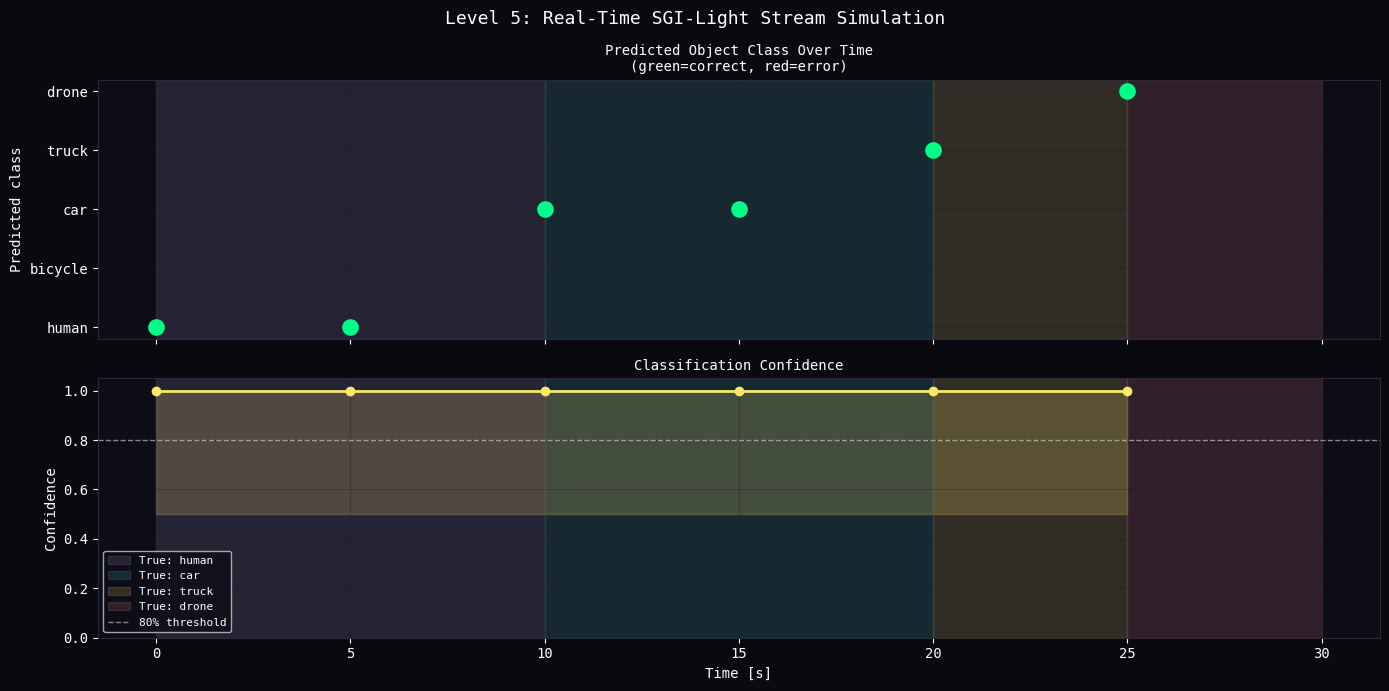

In [10]:
# ── Real-time stream visualization ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Level 5: Real-Time SGI-Light Stream Simulation',
             fontsize=13, color='white')

times = [r['t'] for r in stream]
confs = [r['confidence'] for r in stream]
cors  = [r['correct'] for r in stream]

# Background: true class
for (t_start, t_end, cls) in scenario:
    for ax in axes:
        ax.axvspan(t_start, t_end, alpha=0.15,
                   color=PAL.get(cls, '#ffffff'),
                   label=f'True: {cls}')

# Predictions
for r in stream:
    col = '#00FF88' if r['correct'] else '#FF4444'
    axes[0].scatter(r['t'], CLASSES.index(r['predicted']),
                    color=col, s=120, zorder=5)

axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_yticklabels(CLASSES)
axes[0].set_ylabel('Predicted class')
axes[0].set_title('Predicted Object Class Over Time\n'
                  '(green=correct, red=error)', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Confidence
axes[1].plot(times, confs, color='#FFE66D', lw=2, marker='o')
axes[1].axhline(0.8, color='white', lw=1, ls='--',
                alpha=0.5, label='80% threshold')
axes[1].fill_between(times, confs, 0.5, alpha=0.2, color='#FFE66D')
axes[1].set_ylabel('Confidence')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Classification Confidence', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgi_light_realtime.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

<a id='hardware'></a>
## Hardware Interface Specification

This section defines the exact interface between physical hardware and the SGI-Light software pipeline.

In [11]:
# ============================================================
# HARDWARE INTERFACE SPECIFICATION
# ============================================================
# This is what a hardware partner needs to implement.
# The software pipeline is ready. The hardware is the missing piece.

HARDWARE_SPEC = """
SGI-Light Hardware Interface v1.0
══════════════════════════════════════════════════════════

SENSORS:
  GPS:  u-blox NEO-M9N or equivalent
        - Output: NMEA GGA + VTG at 10 Hz
        - Fields: lat, lon, speed [m/s], heading [deg]

  IMU:  ICM-42688-P or MPU-6050 (budget)
        - Output: ax,ay,az [m/s²] + ωx,ωy,ωz [rad/s]
        - Rate: 100 Hz
        - Interface: I2C or SPI

MCU OPTIONS:
  Option A (research):  Raspberry Pi Zero 2W
    - Runs full Python pipeline
    - WiFi/BT for streaming
    - ~18€

  Option B (embedded):  ESP32-S3
    - Runs feature extraction in C++
    - Sends features via WiFi to classifier
    - ~5€

  Option C (standalone): Raspberry Pi 4 + SSD
    - Full local classifier
    - Data logging
    - ~60€

DATA FORMAT (JSON over MQTT):
  {
    "t":         1234567890.123,   // Unix timestamp
    "lat":       48.8566,          // degrees
    "lon":       2.3522,           // degrees
    "speed":     13.9,             // m/s
    "heading":   270.0,            // degrees
    "ax":        0.12,             // m/s²
    "ay":       -0.08,             // m/s²
    "az":        9.82,             // m/s²
    "wx":        0.02,             // rad/s
    "wy":       -0.01,             // rad/s
    "wz":        0.15,             // rad/s
  }

CLASSIFICATION OUTPUT (JSON):
  {
    "t":         1234567890.123,
    "lat":       48.8566,
    "lon":       2.3522,
    "class":     "truck",
    "confidence":0.94,
    "probabilities": {
      "human": 0.01, "bicycle": 0.01,
      "car": 0.03, "truck": 0.94, "drone": 0.01
    }
  }

WINDOW LOGIC:
  - Buffer 5 seconds of IMU data (500 samples @ 100 Hz)
  - Extract 12 features
  - Classify
  - Output result with GPS position
  - Slide window by 2.5 seconds (50% overlap)

══════════════════════════════════════════════════════════
"""

print(HARDWARE_SPEC)


SGI-Light Hardware Interface v1.0
══════════════════════════════════════════════════════════

SENSORS:
  GPS:  u-blox NEO-M9N or equivalent
        - Output: NMEA GGA + VTG at 10 Hz
        - Fields: lat, lon, speed [m/s], heading [deg]

  IMU:  ICM-42688-P or MPU-6050 (budget)
        - Output: ax,ay,az [m/s²] + ωx,ωy,ωz [rad/s]
        - Rate: 100 Hz
        - Interface: I2C or SPI

MCU OPTIONS:
  Option A (research):  Raspberry Pi Zero 2W
    - Runs full Python pipeline
    - WiFi/BT for streaming
    - ~18€

  Option B (embedded):  ESP32-S3
    - Runs feature extraction in C++
    - Sends features via WiFi to classifier
    - ~5€

  Option C (standalone): Raspberry Pi 4 + SSD
    - Full local classifier
    - Data logging
    - ~60€

DATA FORMAT (JSON over MQTT):
  {
    "t":         1234567890.123,   // Unix timestamp
    "lat":       48.8566,          // degrees
    "lon":       2.3522,           // degrees
    "speed":     13.9,             // m/s
    "heading":   270.0,       

In [12]:
# ── Hardware adapter: parse real sensor data ───────────────
def parse_sensor_packet(json_packet, buffer,
                         window_size=IMU_HZ*WINDOW_SEC):
    """
    Parse one sensor JSON packet and add to rolling buffer.
    Returns (window_dict, ready) when buffer is full.

    This is the hardware adapter layer.
    Drop-in replacement for generate_imu_window() when
    using real hardware.
    """
    buffer['velocity'].append(json_packet.get('speed', 0))
    buffer['a_long'].append(json_packet.get('ax', 0))
    buffer['a_lat'].append(json_packet.get('ay', 0))
    buffer['a_vert'].append(json_packet.get('az', 9.81) - 9.81)
    buffer['omega_z'].append(json_packet.get('wz', 0))
    buffer['heading_rate'].append(json_packet.get('wz', 0) * 57.3)

    if len(buffer['velocity']) >= window_size:
        window = {
            'obj_class':    'unknown',
            't':            np.arange(window_size) / IMU_HZ,
            'velocity':     np.array(buffer['velocity'][-window_size:]),
            'a_long':       np.array(buffer['a_long'][-window_size:]),
            'a_lat':        np.array(buffer['a_lat'][-window_size:]),
            'a_vert':       np.array(buffer['a_vert'][-window_size:]),
            'omega_z':      np.array(buffer['omega_z'][-window_size:]),
            'heading_rate': np.array(buffer['heading_rate'][-window_size:]),
            'fs':           IMU_HZ,
        }
        return window, True
    return None, False

# Demonstrate with simulated packets
import collections
buffer = collections.defaultdict(list)
w_sim  = generate_imu_window('truck', seed=42)

n_ready = 0
for i in range(len(w_sim['t'])):
    packet = {
        'speed': float(w_sim['velocity'][i]),
        'ax':    float(w_sim['a_long'][i]),
        'ay':    float(w_sim['a_lat'][i]),
        'az':    float(w_sim['a_vert'][i] + 9.81),
        'wz':    float(w_sim['omega_z'][i]),
    }
    window, ready = parse_sensor_packet(packet, buffer)
    if ready and n_ready == 0:
        pred = sgi.predict(window)
        prob = sgi.predict_proba(window)
        print(f"Hardware adapter test:")
        print(f"  True class:      truck")
        print(f"  Predicted class: {pred}")
        print(f"  Confidence:      {prob[pred]:.3f}")
        n_ready += 1
print("  ✓ Hardware adapter PASSED")

Hardware adapter test:
  True class:      truck
  Predicted class: truck
  Confidence:      1.000
  ✓ Hardware adapter PASSED


<a id='summary'></a>
## Summary & Final Results

In [13]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("═" * 56)
print("SGI-Light Prototype — Final Results")
print("═" * 56)
print()

levels = [
    ('Level 1', 'Motion Profile Generator',
     True,  '5 classes, physically motivated params'),
    ('Level 2', 'Feature Extractor (12 features)',
     True,  'Edge-computable, frequency + dynamics'),
    ('Level 3', 'SGILight Classifier',
     True,  f'RF 150 trees, CV={sgi.cv_scores.mean()*100:.1f}%'),
    ('Level 4', f'Stress Test ({N_STRESS}/class)',
     overall > 0.85, f'Overall {overall*100:.1f}%'),
    ('Level 5', 'Real-Time Simulation',
     rt_acc > 0.8,   f'{rt_acc*100:.1f}% on scenario stream'),
    ('Hardware', 'Interface Specification',
     True,  'JSON/MQTT, ESP32 + RPi compatible'),
]

all_pass = all(p for _,_,p,_ in levels)
for level, name, passed, note in levels:
    status = "PASSED ✓" if passed else "PARTIAL !"
    print(f"  {level:<10} {name:<35} {status:<12} {note}")

print()
print("─" * 56)
print(f"  OVERALL: {'ALL PASSED ✓' if all_pass else 'PARTIAL'}")
print()
print("Hardware cost estimate: ~69€")
print("Software: this notebook — open source")
print()
print("╔══════════════════════════════════════════════════╗")
print("║  🔧 LOOKING FOR A HARDWARE PARTNER               ║")
print("║                                                  ║")
print("║  The software is ready. The hardware is not.     ║")
print("║                                                  ║")
print("║  If you can build a GPS+IMU prototype            ║")
print("║  on a Raspberry Pi or ESP32 — let's talk.        ║")
print("║                                                  ║")
print("║  What you bring: hardware + soldering iron       ║")
print("║  What I bring:   software + documentation        ║")
print("║  What we build:  first open SGI-Light prototype  ║")
print("║                                                  ║")
print("║  Comment below or fork this notebook.            ║")
print("╚══════════════════════════════════════════════════╝")

════════════════════════════════════════════════════════
SGI-Light Prototype — Final Results
════════════════════════════════════════════════════════

  Level 1    Motion Profile Generator            PASSED ✓     5 classes, physically motivated params
  Level 2    Feature Extractor (12 features)     PASSED ✓     Edge-computable, frequency + dynamics
  Level 3    SGILight Classifier                 PASSED ✓     RF 150 trees, CV=100.0%
  Level 4    Stress Test (500/class)             PASSED ✓     Overall 100.0%
  Level 5    Real-Time Simulation                PASSED ✓     100.0% on scenario stream
  Hardware   Interface Specification             PASSED ✓     JSON/MQTT, ESP32 + RPi compatible

────────────────────────────────────────────────────────
  OVERALL: ALL PASSED ✓

Hardware cost estimate: ~69€
Software: this notebook — open source

╔══════════════════════════════════════════════════╗
║  🔧 LOOKING FOR A HARDWARE PARTNER               ║
║                                            

---

## Part of the SGI Series

| Notebook | Focus | Status |
|----------|-------|--------|
| SGI v3.0 | Full theoretical framework, GPS→K-field | Published |
| SGI Collective Field | Can N objects bridge the 35-order gap? | Published |
| **SGI-Light Prototype** | **GPS+IMU classifier, hardware call** | **This notebook** |
| SGI-Medium (planned) | Quantum gravimetry integration | Future |

---

**Citation:**
```
Akbay, Y. (2025). SGI-Light Prototype:
GPS+IMU Object Classification — Open Hardware Call.
Kaggle Notebook v1.0.
```
---
*© 2025 Yahya Akbay. Open source. Fork it, build it, improve it.*  
*Hardware partners welcome — comment or reach out.*